In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from m5_wrmsse import wrmsse
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

In [3]:
train=pd.read_csv("../m5-forecasting-accuracy/train.csv")
test=pd.read_csv("../m5-forecasting-accuracy/test.csv")

In [4]:
def prepare_data(df):
    df = df.copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')
    
    y = df['sales']
    X = df.drop(['sales', 'date'], axis=1)
    
    return X, y

In [5]:
X_train, y_train = prepare_data(train)
X_test, y_test = prepare_data(test)

In [6]:
categorical_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1']
categorical_cols = [c for c in categorical_cols if c in X_train.columns]
numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

In [7]:
# Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)) 
    # Für Quantum oft besser Ordinal statt OneHot wegen Qubit-Anzahl Limitierung
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [8]:
# ML Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42, max_depth=10))
])
# TODO: Multiple Models
# TODO: Focus on Hierarical Data

In [ ]:
# Training
model.fit(X_train, y_train)
# TODO: Progress Bar

In [ ]:
# Evaluation
y_pred = model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# MRMSSE Calculation
train_series = train.set_index(['store_id', 'item_id', 'date'])['sales'].unstack(level='date').sort_index(axis=1)

# Calculate sum of squared errors for the naive forecast (lag 1) on training data
naive_errors = (train_series.diff(axis=1) ** 2).sum(axis=1)
# N is the number of time points - 1 (because of diff)
n_train = train_series.shape[1] - 1
scaling_factor = naive_errors / n_train

# 2. Calculate the numerator (MSE of the forecast)
# We need to align y_test and y_pred with the same index structure
test_df_eval = test.copy()
test_df_eval['pred'] = y_pred
test_df_eval['actual'] = y_test

# Group by series identifier to calculate MSE per series
mse_series = test_df_eval.groupby(['store_id', 'item_id']).apply(
    lambda x: mean_squared_error(x['actual'], x['pred'])
)

# 3. Calculate RMSSE per series
# Align indexes
common_index = mse_series.index.intersection(scaling_factor.index)
mse_series_aligned = mse_series.loc[common_index]
scaling_factor_aligned = scaling_factor.loc[common_index]

# Avoid division by zero by replacing 0 with a small epsilon or handling separately
rmsse_series = np.sqrt(mse_series_aligned / (scaling_factor_aligned + 1e-10))

# 4. Average to get MRMSSE
mrmsse = rmsse_series.mean()

print(f"MRMSSE: {mrmsse:.4f}")
# TODO: Use MRMSSE calculation of https://www.pmorgan.com.au/tutorials/wrmsse-for-the-m5-dataset/ (bottom of page)

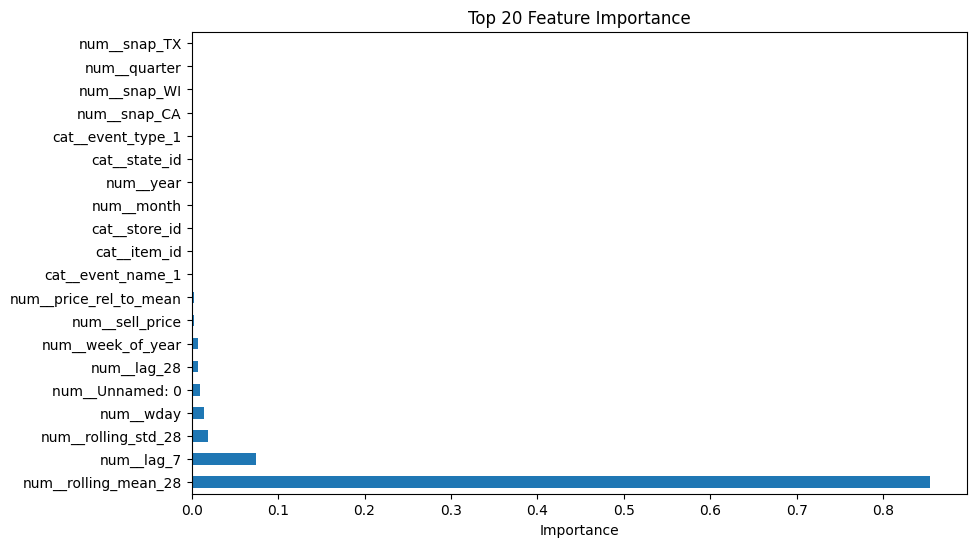

In [ ]:
# Optional: Feature Importance anzeigen (nur bei Tree-Modellen einfach möglich)
if hasattr(model.named_steps['regressor'], 'feature_importances_'):
    import matplotlib.pyplot as plt
    
    # Extract feature importances
    ft_imp = model.named_steps['regressor'].feature_importances_
    
    # Extract feature names from the preprocessor
    # Note: This method requires scikit-learn >= 1.0
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    
    # Create a DataFrame for better visualization
    feat_importances = pd.Series(ft_imp, index=feature_names)
    
    # Plot top 20 features
    plt.figure(figsize=(10, 6))
    feat_importances.nlargest(20).plot(kind='barh')
    plt.title("Top 20 Feature Importance")
    plt.xlabel("Importance")
    plt.show()

# Speichern der Pipeline für spätere Nutzung
# joblib.dump(model, 'tsf_pipeline.pkl')